# Test Systems: A (Template) vs B (Enc-Dec)

Evaluate both sarcasm-rewriting systems on the **dev set** using three automatic metrics:

| Metric | What it measures |
|---|---|
| **Anchor preservation** | Do named entities, numbers, etc. survive the rewrite? |
| **Semantic similarity** | Does the rewrite stay on topic? (sentence-transformer cosine sim) |
| **Classifier flip rate** | Does a trained classifier predict the *target* label on the rewrite? |

Each headline is rewritten in its natural direction:
- label=0 (neutral) → rewrite to sarcastic (**n2s**)
- label=1 (sarcastic) → rewrite to neutral (**s2n**)

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

print(f"Project root: {PROJECT_ROOT}")

Project root: E:\CS4248_Project


## 1. Load dev set (with anchors)

In [2]:
SPLIT_NAME = "standard"

df_all = pd.read_json("../artifacts/data/cleaned_with_anchors.jsonl", lines=True)

with open(f"../artifacts/splits/{SPLIT_NAME}.json", "r", encoding="utf-8") as f:
    split = json.load(f)

dev_ids = set(split["dev"])
dev_df = df_all[df_all["id"].isin(dev_ids)].copy().reset_index(drop=True)

print(f"Split: {SPLIT_NAME}")
print(f"Dev set: {len(dev_df)} rows")
print(f"  label=0 (neutral):   {(dev_df['label'] == 0).sum()}")
print(f"  label=1 (sarcastic): {(dev_df['label'] == 1).sum()}")
dev_df[["id", "text", "label"]].head()

Split: standard
Dev set: 2850 rows
  label=0 (neutral):   1495
  label=1 (sarcastic): 1355


,id,text,label
0,sar_000003,eat your veggies: 9 deliciously different recipes,0
1,sar_000011,this lesbian is considered a father in indiana...,0
2,sar_000015,ford develops new suv that runs purely on gaso...,1
3,sar_000020,lin-manuel miranda would like to remind you to...,0
4,sar_000022,guard in video game under strict orders to rep...,1


## 2. Initialize systems and evaluation tools

In [3]:
from systems.system_a.system_a_template import SystemATemplate
from systems.system_b_encdec import generate_candidates as system_b_generate, batch_generate as system_b_batch
from systems.system_a.template_utils import preserves_anchors, get_anchor_texts
from similarity.semantic_similarity import semantic_similarity, batch_semantic_similarity

system_a = SystemATemplate()

print("System A (Template):  ready")
print("System B (Enc-Dec):   loading model on first call...")


def direction_for_label(label: int) -> str:
    return "n2s" if label == 0 else "s2n"


def target_label(label: int) -> int:
    return 1 if label == 0 else 0

System A (Template):  ready
System B (Enc-Dec):   loading model on first call...


## 3. Load the trained classifier (for flip-rate evaluation)

We use the LogReg model trained on the standard split — it's fast and doesn't need a GPU.

In [4]:
import joblib

LOGREG_MODEL_PATH = PROJECT_ROOT / "artifacts" / "classifiers" / "logreg" / SPLIT_NAME / "model.joblib"
clf = joblib.load(LOGREG_MODEL_PATH)
print(f"Loaded classifier from {LOGREG_MODEL_PATH}")


def classify_text(text: str) -> tuple[int, float]:
    """Return (predicted_label, prob_sarcastic) for a single text."""
    prob = clf.predict_proba([text])[0, 1]
    return int(prob >= 0.5), float(prob)


test_pred, test_prob = classify_text("Nation relieved as experts confirm everything is fine")
print(f"Test: pred={test_pred}, prob_sarcastic={test_prob:.3f}")

Loaded classifier from E:\CS4248_Project\artifacts\classifiers\logreg\standard\model.joblib
Test: pred=1, prob_sarcastic=0.849


## 4. Run both systems on the dev set

The evaluation runs in three phases to avoid per-row bottlenecks:

1. **Rewrite** — collect rewrites from both systems (System B is the slowest step)
2. **Score similarity** — batch-encode all texts with the sentence-transformer, then compute cosine similarity
3. **Score classifier** — batch-predict all rewrites with LogReg in one call

In [5]:
# ========== PHASE 1: collect rewrites ==========
# System A is template-based (instant), so run it in a fast loop.
all_texts = dev_df["text"].tolist()
all_labels = dev_df["label"].astype(int).tolist()
all_anchors = [row.get("anchors", {}) for _, row in dev_df.iterrows()]
all_directions = [direction_for_label(l) for l in all_labels]

print("Phase 1a · System A rewrites (template)...")
rewrites_a = [
    system_a.rewrite(t, a, d)
    for t, a, d in tqdm(zip(all_texts, all_anchors, all_directions),
                        total=len(all_texts), desc="System A")
]

# System B: batched GPU generation — much faster than one-by-one.
BATCH_SIZE = 16
n_batches = (len(all_texts) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Phase 1b · System B rewrites ({n_batches} batches, batch_size={BATCH_SIZE})...")

rewrites_b_lists = []
for i in tqdm(range(0, len(all_texts), BATCH_SIZE), total=n_batches, desc="System B (batched)"):
    chunk = system_b_batch(
        all_texts[i : i + BATCH_SIZE],
        all_directions[i : i + BATCH_SIZE],
        k=1, batch_size=BATCH_SIZE,
    )
    rewrites_b_lists.extend(chunk)
rewrites_b = [cands[0] for cands in rewrites_b_lists]

eval_df = pd.DataFrame({
    "id": dev_df["id"].tolist(),
    "label": all_labels,
    "direction": all_directions,
    "target_label": [target_label(l) for l in all_labels],
    "original": all_texts,
    "anchors": all_anchors,
    "rewrite_a": rewrites_a,
    "rewrite_b": rewrites_b,
})

print(f"Phase 1 done — {len(eval_df)} rewrites collected.")

# ========== PHASE 2: batch semantic similarity ==========
print("Phase 2 · computing semantic similarity (batched)...")
originals = eval_df["original"].tolist()
eval_df["sim_a"] = batch_semantic_similarity(originals, eval_df["rewrite_a"].tolist())
eval_df["sim_b"] = batch_semantic_similarity(originals, eval_df["rewrite_b"].tolist())
print("Phase 2 done.")

# ========== PHASE 3: batch classify + anchor check ==========
print("Phase 3 · classifier predictions + anchor checks...")
probs_a = clf.predict_proba(eval_df["rewrite_a"].tolist())[:, 1]
probs_b = clf.predict_proba(eval_df["rewrite_b"].tolist())[:, 1]

eval_df["prob_a"] = probs_a
eval_df["pred_a"] = (probs_a >= 0.5).astype(int)
eval_df["flip_a"] = (eval_df["pred_a"] == eval_df["target_label"]).astype(int)

eval_df["prob_b"] = probs_b
eval_df["pred_b"] = (probs_b >= 0.5).astype(int)
eval_df["flip_b"] = (eval_df["pred_b"] == eval_df["target_label"]).astype(int)

eval_df["anchor_ok_a"] = [
    preserves_anchors(a, r) for a, r in zip(eval_df["anchors"], eval_df["rewrite_a"])
]
eval_df["anchor_ok_b"] = [
    preserves_anchors(a, r) for a, r in zip(eval_df["anchors"], eval_df["rewrite_b"])
]

print(f"All phases complete — {len(eval_df)} rows.")
eval_df.head()

Phase 1a · System A rewrites (template)...


System A:   0%|          | 0/2850 [00:00<?, ?it/s]

Phase 1b · System B rewrites (179 batches, batch_size=16)...


System B (batched):   0%|          | 0/179 [00:00<?, ?it/s]

Phase 1 done — 2850 rewrites collected.
Phase 2 · computing semantic similarity (batched)...
Phase 2 done.
Phase 3 · classifier predictions + anchor checks...
All phases complete — 2850 rows.


,id,label,direction,target_label,original,anchors,rewrite_a,rewrite_b,sim_a,sim_b,prob_a,pred_a,flip_a,prob_b,pred_b,flip_b,anchor_ok_a,anchor_ok_b
0,sar_000003,0,n2s,1,eat your veggies: 9 deliciously different recipes,"{'entities': [], 'numbers': [{'text': '9', 'st...",eat your veggies: 9 deliciously different reci...,"Vegetables will not fit on the fridge, let's m...",0.935684,0.743432,0.140977,0,0,0.331197,0,0,True,False
1,sar_000011,0,n2s,1,this lesbian is considered a father in indiana...,"{'entities': [{'text': 'indiana', 'start': 39,...",Experts confirm this lesbian is considered a f...,The father of an Indian family is called my ni...,0.982918,0.626630,0.078935,0,0,0.021765,0,0,True,False
2,sar_000015,1,s2n,0,ford develops new suv that runs purely on gaso...,"{'entities': [{'text': 'ford', 'start': 0, 'en...",ford develops new suv that runs purely on gaso...,Ford introduces next to power plants. Ford eng...,1.000000,0.793173,0.812470,1,0,0.147790,0,1,True,True
3,sar_000020,0,n2s,1,lin-manuel miranda would like to remind you to...,"{'entities': [{'text': 'lin-manuel miranda', '...",Experts confirm lin-manuel miranda would like ...,President François Hollande would much rather ...,0.979483,0.576130,0.473772,0,0,0.890712,1,1,True,False
4,sar_000022,1,s2n,0,guard in video game under strict orders to rep...,"{'entities': [], 'numbers': [], 'capitals': []...",guard in video game under strict orders to rep...,"guard says ""it's our decision to let everyone ...",1.000000,0.688942,0.803430,1,0,0.310026,0,1,True,True


## 5. Aggregate metrics

In [6]:
def summarize_system(eval_df, suffix):
    """Summarize metrics for one system (suffix = '_a' or '_b')."""
    return {
        "Anchor preservation (%)": eval_df[f"anchor_ok{suffix}"].mean() * 100,
        "Semantic similarity (mean)": eval_df[f"sim{suffix}"].mean(),
        "Classifier flip rate (%)": eval_df[f"flip{suffix}"].mean() * 100,
    }


overall = pd.DataFrame({
    "System A (Template)": summarize_system(eval_df, "_a"),
    "System B (Enc-Dec)": summarize_system(eval_df, "_b"),
}).round(2)

print(f"=== OVERALL — {SPLIT_NAME} split (both directions combined) ===\n")
display(overall)

=== OVERALL — standard split (both directions combined) ===



,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,59.96
Semantic similarity (mean),0.98,0.74
Classifier flip rate (%),24.35,37.96


In [7]:
print("=== BREAKDOWN BY DIRECTION ===\n")

for direction, label_name in [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]:
    sub = eval_df[eval_df["direction"] == direction]
    breakdown = pd.DataFrame({
        "System A (Template)": summarize_system(sub, "_a"),
        "System B (Enc-Dec)": summarize_system(sub, "_b"),
    }).round(2)
    print(f"\n--- {label_name}  ({len(sub)} headlines) ---")
    display(breakdown)

=== BREAKDOWN BY DIRECTION ===


--- Neutral → Sarcastic  (1495 headlines) ---


,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,56.59
Semantic similarity (mean),0.97,0.74
Classifier flip rate (%),34.18,18.93



--- Sarcastic → Neutral  (1355 headlines) ---


,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,63.69
Semantic similarity (mean),1.00,0.73
Classifier flip rate (%),13.51,58.97


## 6. Visualize comparison

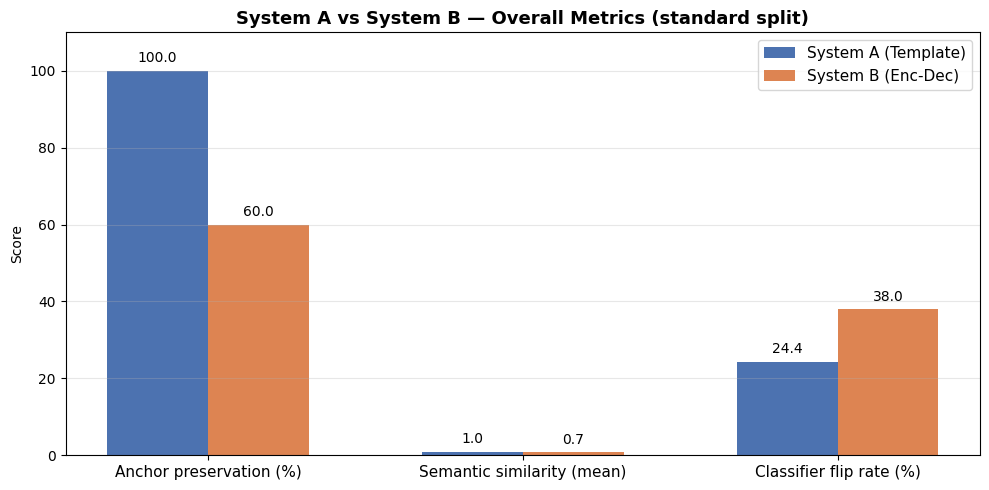

In [8]:
import matplotlib.pyplot as plt

metrics_names = list(overall.index)
sys_a_vals = overall["System A (Template)"].values
sys_b_vals = overall["System B (Enc-Dec)"].values

x = np.arange(len(metrics_names))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, sys_a_vals, width, label="System A (Template)", color="#4c72b0")
bars2 = ax.bar(x + width / 2, sys_b_vals, width, label="System B (Enc-Dec)", color="#dd8452")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel("Score")
ax.set_title(f"System A vs System B — Overall Metrics ({SPLIT_NAME} split)", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

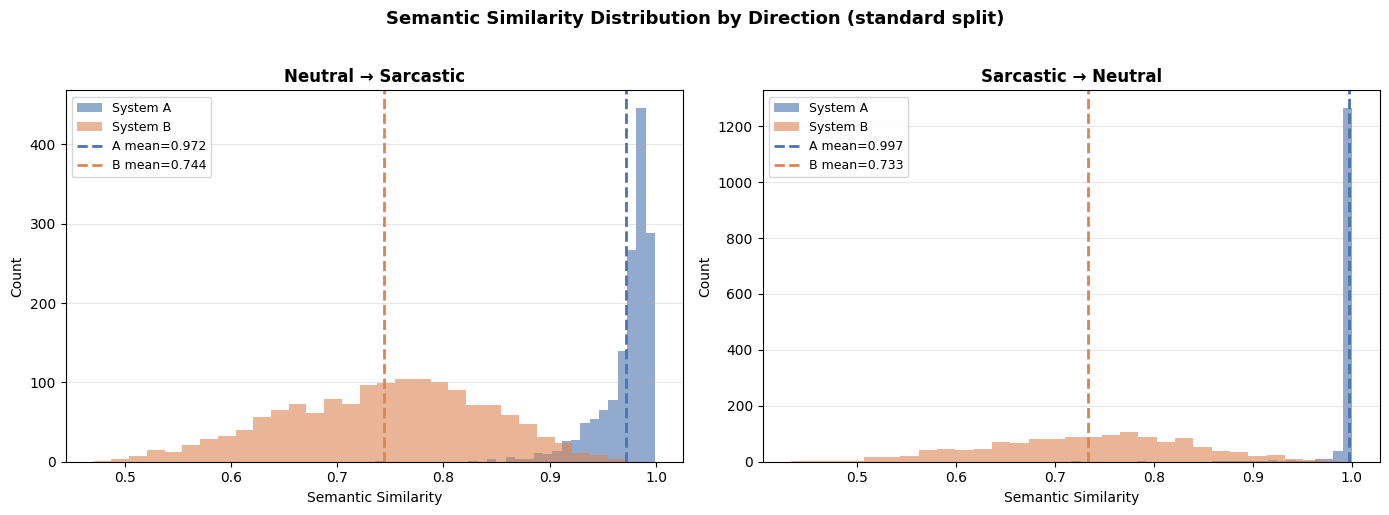

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (direction, title) in zip(axes, [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]):
    sub = eval_df[eval_df["direction"] == direction]

    sim_a = sub["sim_a"]
    sim_b = sub["sim_b"]

    ax.hist(sim_a, bins=30, alpha=0.6, label="System A", color="#4c72b0")
    ax.hist(sim_b, bins=30, alpha=0.6, label="System B", color="#dd8452")
    ax.axvline(sim_a.mean(), color="#4c72b0", linestyle="--", linewidth=2, label=f"A mean={sim_a.mean():.3f}")
    ax.axvline(sim_b.mean(), color="#dd8452", linestyle="--", linewidth=2, label=f"B mean={sim_b.mean():.3f}")
    ax.set_xlabel("Semantic Similarity")
    ax.set_ylabel("Count")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"Semantic Similarity Distribution by Direction ({SPLIT_NAME} split)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Sample rewrites (qualitative inspection)

Spot-check a few examples from each system and direction.

In [10]:
N_SAMPLES = 5

for direction, title in [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]:
    sub = eval_df[eval_df["direction"] == direction].sample(N_SAMPLES, random_state=42)
    print(f"\n{'='*80}")
    print(f"  {title}")
    print(f"{'='*80}")

    for _, r in sub.iterrows():
        print(f"\n  ORIGINAL : {r['original']}")
        print(f"  SYSTEM A : {r['rewrite_a']}")
        print(f"    anchor={r['anchor_ok_a']}  sim={r['sim_a']:.3f}  flip={r['flip_a']}")
        print(f"  SYSTEM B : {r['rewrite_b']}")
        print(f"    anchor={r['anchor_ok_b']}  sim={r['sim_b']:.3f}  flip={r['flip_b']}")
        print(f"  {'-'*76}")


  Neutral → Sarcastic

  ORIGINAL : georgia executes gregory lawler for killing police officer, despite autism defense
  SYSTEM A : Experts confirm georgia executes gregory lawler for killing police officer, despite autism defense
    anchor=True  sim=0.986  flip=0
  SYSTEM B : georgia sentenced georgia school psychologist Neil Gao an execution. but it was too early to.
    anchor=False  sim=0.768  flip=0
  ----------------------------------------------------------------------------

  ORIGINAL : senate republicans just killed their health care bill again
  SYSTEM A : Nation relieved as senate republicans just killed their health care bill again
    anchor=True  sim=0.930  flip=1
  SYSTEM B : New republicans and whites are at odds on the state of public safety. Politicians blame social problems on GOP.
    anchor=False  sim=0.650  flip=0
  ----------------------------------------------------------------------------

  ORIGINAL : 10 things no one told me before my c-section
  SYSTEM A 

## 8. Verdict

In [11]:
print("=" * 60)
print(f"  SYSTEM COMPARISON SUMMARY  ({SPLIT_NAME} split)")
print("=" * 60)

for metric in metrics_names:
    va = overall.loc[metric, "System A (Template)"]
    vb = overall.loc[metric, "System B (Enc-Dec)"]
    winner = "A" if va > vb else ("B" if vb > va else "tie")
    print(f"  {metric:35s}  A={va:6.2f}  B={vb:6.2f}  → {'System ' + winner if winner != 'tie' else 'TIE'}")

print()

flip_a = eval_df["flip_a"].mean() * 100
flip_b = eval_df["flip_b"].mean() * 100
anchor_a = eval_df["anchor_ok_a"].mean() * 100
anchor_b = eval_df["anchor_ok_b"].mean() * 100

if flip_b > flip_a + 2:
    print("  System B (Enc-Dec) achieves a meaningfully higher flip rate,")
    print("  suggesting its generative rewrites are more effective at fooling")
    print("  the classifier. Check anchor preservation and similarity to see")
    print("  if it trades off faithfulness for this gain.")
elif flip_a > flip_b + 2:
    print("  System A (Template) achieves a higher flip rate despite being")
    print("  rule-based, which may indicate the classifier is sensitive to")
    print("  template-like sarcastic cues (prefixes/suffixes).")
else:
    print("  Both systems have similar flip rates. The choice may depend on")
    print("  semantic similarity and anchor preservation trade-offs.")

print("=" * 60)

  SYSTEM COMPARISON SUMMARY  (standard split)
  Anchor preservation (%)              A=100.00  B= 59.96  → System A
  Semantic similarity (mean)           A=  0.98  B=  0.74  → System A
  Classifier flip rate (%)             A= 24.35  B= 37.96  → System B

  System B (Enc-Dec) achieves a meaningfully higher flip rate,
  suggesting its generative rewrites are more effective at fooling
  the classifier. Check anchor preservation and similarity to see
  if it trades off faithfulness for this gain.


## 8. Save sample conversions for human evaluation

Export a stratified random sample of rewrites for manual review. The CSV contains the original headline, both system rewrites, automatic scores, and blank columns for human ratings.

In [12]:
SAMPLE_N = 50
SEED = 42
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "human_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample_frames = []
for direction in ["n2s", "s2n"]:
    subset = eval_df[eval_df["direction"] == direction]
    n = min(SAMPLE_N // 2, len(subset))
    sample_frames.append(subset.sample(n=n, random_state=SEED))

sample_df = pd.concat(sample_frames).sample(frac=1, random_state=SEED).reset_index(drop=True)

human_df = sample_df[[
    "id", "direction", "original",
    "rewrite_a", "sim_a", "flip_a", "anchor_ok_a",
    "rewrite_b", "sim_b", "flip_b", "anchor_ok_b",
]].copy()

human_df["human_fluency_a"] = ""
human_df["human_adequacy_a"] = ""
human_df["human_sarcasm_a"] = ""
human_df["human_fluency_b"] = ""
human_df["human_adequacy_b"] = ""
human_df["human_sarcasm_b"] = ""
human_df["human_preference"] = ""

out_path = OUTPUT_DIR / f"samples_{SPLIT_NAME}.csv"
human_df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Saved {len(human_df)} samples -> {out_path}")
human_df.head()

Saved 50 samples -> E:\CS4248_Project\artifacts\human_eval\samples_standard.csv


,id,direction,original,rewrite_a,sim_a,flip_a,anchor_ok_a,rewrite_b,sim_b,flip_b,anchor_ok_b,human_fluency_a,human_adequacy_a,human_sarcasm_a,human_fluency_b,human_adequacy_b,human_sarcasm_b,human_preference
0,sar_026442,n2s,senators rip obama's 'flexible' interpretation...,Nation relieved as senators rip obama's 'flexi...,0.975412,1,True,Politicians have to learn not to fall for this...,0.688312,0,False,,,,,,,
1,sar_009028,s2n,boss wants to know if you can work late this year,boss wants to know if you can work late this year,1.000000,1,True,Boris Reis is still going to wear polar grey a...,0.553436,1,True,,,,,,,
2,sar_015171,s2n,"disgruntled bolton shoots 17 un delegates, self","disgruntled bolton shoots 17 un delegates, self",1.000000,0,True,Envoy: gov to defend Obama in New Mexico court...,0.601994,1,False,,,,,,,
3,sar_011743,s2n,woodpecker having difficulty remembering tree ...,woodpecker having difficulty remembering tree ...,1.000000,0,True,A birder in Iowa claims he was too nervous to ...,0.771763,1,True,,,,,,,
4,sar_007005,n2s,north korea says it's open to talking denuclea...,Experts confirm north korea says it's open to ...,0.989767,0,True,the big whites won't support repressing north ...,0.656139,0,False,,,,,,,
